In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/PS_20174392719_1491204439457_log.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.shape

(6362620, 11)

In [4]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [5]:
df.groupby("type")["isFraud"].mean().sort_values(ascending=False)

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

#### Fraud Transactions mostly happen in type - TRANSFER & CASH_OUT

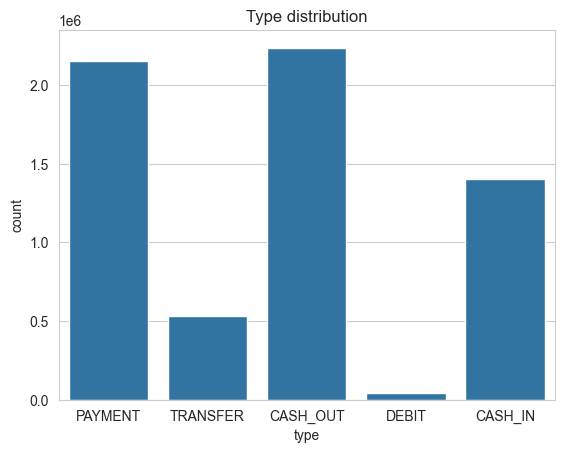

In [6]:
sns.countplot(data=df, x="type")
plt.title("Type distribution")
plt.show()

In [7]:
#Balance Behaviour:
df["balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]


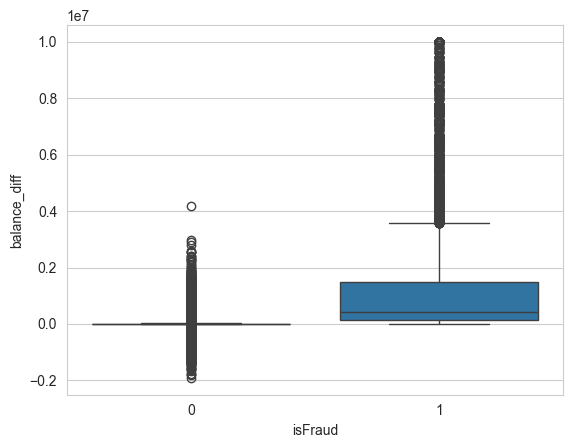

In [8]:
sns.boxplot(data=df, x="isFraud", y="balance_diff")
plt.show()

##### From boxplot: Fraud Transactions (1) - exhibit significantly higher balance reductions compared to legitimate transactions (even full account clearing)

In [9]:
# Feature Engineering 1: Hour of the Day

df["hour"] = df["step"] % 24

In [10]:
# Feature Engineering 2: Day Number
df["day"] = df["step"] // 24

In [11]:
df["is_night"] = df["hour"].isin([0, 1, 2, 3, 4, 5]).astype(int)

In [12]:
df[["hour", "is_night"]].head(10)
print(df["is_night"].value_counts())

is_night
0    6250015
1     112605
Name: count, dtype: int64


In [13]:
# Feature Engineering 4: Happen during business hours?
df["is_business_hours"] = df["hour"].between(9, 18).astype(int)

In [14]:
df["is_business_hours"].value_counts()

is_business_hours
1    4425532
0    1937088
Name: count, dtype: int64

In [15]:
# Feature 5: Night Transfer or Cash Out

df["night_transfer_cashout"] = ((df["is_night"] == 1) & df["type"].isin(["TRANSFER", "CASH_OUT"])).astype(int)

In [16]:
df[["type", "hour", "is_night", "night_transfer_cashout"]].head(10)

,type,hour,is_night,night_transfer_cashout
0,PAYMENT,1,1,0
1,PAYMENT,1,1,0
2,TRANSFER,1,1,1
3,CASH_OUT,1,1,1
4,PAYMENT,1,1,0
5,PAYMENT,1,1,0
6,PAYMENT,1,1,0
7,PAYMENT,1,1,0
8,PAYMENT,1,1,0
9,DEBIT,1,1,0


In [17]:
(df["night_transfer_cashout"].value_counts())

night_transfer_cashout
0    6334555
1      28065
Name: count, dtype: int64

In [18]:
#  Feature 5: Fraud Rate by Hour

hour_fraud_rate = df.groupby("hour")["isFraud"].mean()
hour_fraud_rate


hour
0     0.004191
1     0.013205
2     0.041251
3     0.162431
4     0.220790
5     0.223035
6     0.104678
7     0.036493
8     0.013673
9     0.001203
10    0.000881
11    0.000726
12    0.000701
13    0.000739
14    0.000803
15    0.000818
16    0.000781
17    0.000802
18    0.000591
19    0.000528
20    0.000614
21    0.001400
22    0.001804
23    0.002287
Name: isFraud, dtype: float64

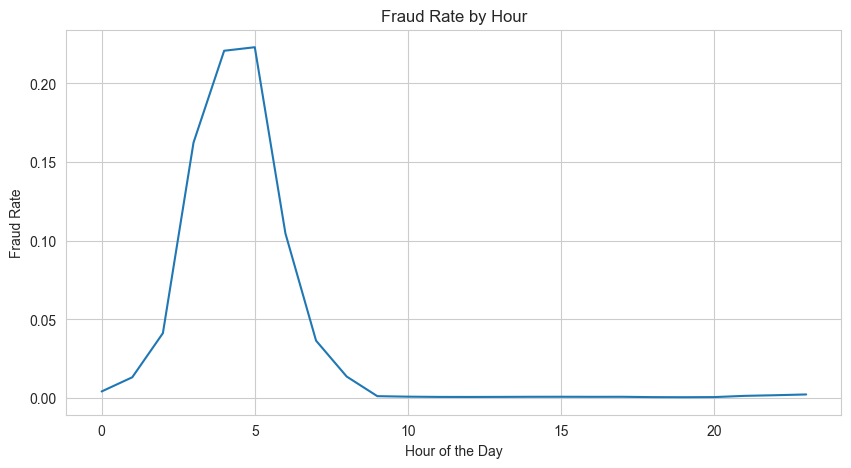

In [19]:
hour_fraud_rate.plot(figsize=(10,5))
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Fraud Rate")
plt.show()

In [20]:
# Feature 6: Time Gap between Transactions
## measure gap between one transaction and the previous transactions from same account

df = df.sort_values(["nameOrig", "step"])
df["time_diff"] = df.groupby("nameOrig")["step"].diff().fillna(0)


In [21]:
df[["nameOrig", "step", "time_diff"]].head(15)

,nameOrig,step,time_diff
3196942,C1000000639,249,0.0
2798983,C1000001337,217,0.0
1013585,C1000001725,46,0.0
2980283,C1000002591,231,0.0
1920204,C1000003372,167,0.0
3374567,C1000003615,254,0.0
4548211,C1000004053,327,0.0
847860,C1000004530,41,0.0
2825292,C1000005353,226,0.0
2202461,C1000005555,185,0.0


In [22]:
# Feature 9: Rapid Transaction Flag
## Flag account making another transaction within very short period of time.
### Quick transactions indicated suspicious behaviour

df["rapid_txn"] = (df["time_diff"] <= 0.1).astype(int)

In [23]:
print(df["rapid_txn"].value_counts())

rapid_txn
1    6353354
0       9266
Name: count, dtype: int64


In [24]:
df.groupby("rapid_txn")["isFraud"].mean()

rapid_txn
0    0.001943
1    0.001290
Name: isFraud, dtype: float64

In [25]:
## To drop rapid_txn as not useful - almost all is 1

In [26]:
print(df.groupby("night_transfer_cashout")["isFraud"].mean())

night_transfer_cashout
0    0.000981
1    0.071121
Name: isFraud, dtype: float64


In [27]:
print(df.groupby("is_night")["isFraud"].mean())

is_night
0    0.000995
1    0.017726
Name: isFraud, dtype: float64


In [28]:
df["time_diff_bucket"] = pd.cut(
    df["time_diff"],
    bins=[-1, 0.1, 1, 24, 1000],
    labels=["Very Fast", "Fast", "Normal", "Slow"]
)

In [29]:
df["rapid_transfer"] = (
    (df["time_diff"] <= 0.1) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
).astype(int)

In [30]:
df.groupby("rapid_txn")["isFraud"].mean()

rapid_txn
0    0.001943
1    0.001290
Name: isFraud, dtype: float64

In [31]:
df.groupby("time_diff_bucket")["isFraud"].mean()

time_diff_bucket
Very Fast    0.001290
Fast         0.000000
Normal       0.001923
Slow         0.001961
Name: isFraud, dtype: float64

In [32]:
df.groupby("rapid_transfer")["isFraud"].mean()

rapid_transfer
0    0.000005
1    0.002962
Name: isFraud, dtype: float64

In [33]:
# Drop Unnecessary column due to bad results (no clear differentiation)
df = df.drop(columns=["rapid_txn", "time_diff", "time_diff_bucket"], errors="ignore")

In [34]:
df.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud',
 'balance_diff',
 'hour',
 'day',
 'is_night',
 'is_business_hours',
 'night_transfer_cashout',
 'rapid_transfer']

In [35]:
df.shape

(6362620, 18)

In [36]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff,hour,day,is_night,is_business_hours,night_transfer_cashout,rapid_transfer
3196942,249,CASH_OUT,244486.46,C1000000639,8946.0,0.00,C785826240,526950.37,771436.84,0,0,8946.00,9,10,0,1,0,1
2798983,217,PAYMENT,3170.28,C1000001337,58089.0,54918.72,M216466820,0.00,0.00,0,0,3170.28,1,9,1,0,0,0


In [37]:
# ML prepare:

features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balance_diff",
    
    "hour",
    "is_night",
    "is_business_hours",
    
    "night_transfer_cashout"
]

target = "isFraud"

X = df[features]
y = df[target]

In [38]:
X.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_diff,hour,is_night,is_business_hours,night_transfer_cashout
3196942,244486.46,8946.00,0.00,526950.37,771436.84,8946.00,9,0,1,0
2798983,3170.28,58089.00,54918.72,0.00,0.00,3170.28,1,1,0,0
1013585,8424.74,783.00,0.00,0.00,0.00,783.00,22,0,0,0
2980283,261877.19,7596.00,269473.19,1126627.70,864750.51,-261877.19,15,0,1,0
1920204,20528.65,2302074.12,2322602.77,82696.17,62167.52,-20528.65,23,0,0,0


In [39]:
# Type - categorical - to change

X = pd.get_dummies(X.join(df["type"]), drop_first=True).astype(int)

In [40]:
X.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_diff,hour,is_night,is_business_hours,night_transfer_cashout,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
3196942,244486,8946,0,526950,771436,8946,9,0,1,0,1,0,0,0
2798983,3170,58089,54918,0,0,3170,1,1,0,0,0,0,1,0
1013585,8424,783,0,0,0,783,22,0,0,0,0,0,1,0
2980283,261877,7596,269473,1126627,864750,-261877,15,0,1,0,0,0,0,0
1920204,20528,2302074,2322602,82696,62167,-20528,23,0,0,0,0,0,0,0


In [41]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [42]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(5090096, 14)
(5090096,)
(1272524, 14)
(1272524,)


In [43]:
# Scale Features 

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
# Logistic Regression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [45]:
# Predict Probabilities:
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]
threshold = 0.5
log_pred = (log_probs >= threshold).astype(int)

In [46]:
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))
print("ROC-AUC  :", roc_auc_score(y_test, log_probs))

Precision: 0.02676339905581783
Recall   : 0.938527084601339
F1 Score : 0.05204272768693363
ROC-AUC  : 0.9910447259463689


In [47]:
print(confusion_matrix(y_test, log_pred))

[[1214807   56074]
 [    101    1542]]


In [48]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.94      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.95      0.51   1272524
weighted avg       1.00      0.96      0.98   1272524



In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": log_model.coef_[0]
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

                   Feature  Importance
3           oldbalanceDest   35.093223
10           type_CASH_OUT   28.350132
13           type_TRANSFER   16.909372
5             balance_diff    3.372665
9   night_transfer_cashout    1.736283
1            oldbalanceOrg    0.957346
2           newbalanceOrig    0.777260
8        is_business_hours   -0.443043
6                     hour   -0.476842
0                   amount   -0.608315


## Matches Fraud Behaviour Patterns:
- Happens via TRANSFER / CASH_OUT
- Happens usually at NIGHT
- Drains Account Balance
- Involves Abnormal Destination Balances

In [50]:
# Trying out Random Forest

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [51]:
rf_probs = rf_model.predict_proba(X_test)[:, 1]
threshold_rf = 0.5
rf_pred = (rf_probs >= threshold_rf).astype(int)

In [52]:
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_probs))

Precision: 0.09131042190556021
Recall   : 0.9945222154595252
F1 Score : 0.16726379363292046
ROC-AUC  : 0.9994552843926663


In [53]:
print(confusion_matrix(y_test, rf_pred))

[[1254620   16261]
 [      9    1634]]


In [54]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(rf_importance.head(10))

           Feature  Importance
5     balance_diff    0.336133
1    oldbalanceOrg    0.150477
0           amount    0.125283
2   newbalanceOrig    0.116630
13   type_TRANSFER    0.065398
4   newbalanceDest    0.041892
12    type_PAYMENT    0.039556
6             hour    0.035352
10   type_CASH_OUT    0.031338
3   oldbalanceDest    0.022888


In [56]:
# XG boost

## Make sure weights are adjusted as there are way more NON-FRAUD then FRAUD
## len(y_train) - total number of FRAUD and NON-FRAUD
## sum(y_train) - total number of FRAUD only (as stated as 1)
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

In [ ]:
# Training of XGBoost

## n_estimators = number of trees - more trees, more learning but slower 
## max_depth = how complex each tree is
## learning_rate = how fast the model learn (lower - more stable, higher - faster but risk of overfitting)
## n_jobs = -1 (Use all CPU cores)
## eval_metric = how model evaluates itself during training (log loss: probability accuracy)


xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, scale_pos_weight= scale_pos_weight, random_state=42, n_jobs=1, eval_metric="logloss")


In [58]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
# Predict probabilities (Probability of it being FRAUD)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

In [60]:
# Predictions - convert probabilities and classify them to FRAUD and NON-FRAUD.

## Threshold - controls trade-ff
threshold = 0.5
xgb_pred = (xgb_probs >= threshold).astype(int)

In [62]:
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_probs))

Precision: 0.18901174844505875
Recall   : 0.9987827145465612
F1 Score : 0.31786924939467315
ROC-AUC  : 0.9998742872252622


In [63]:
print(confusion_matrix(y_test, xgb_pred))

[[1263840    7041]
 [      2    1641]]


In [64]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(xgb_importance.head(10))

                   Feature  Importance
5             balance_diff    0.541932
9   night_transfer_cashout    0.105570
12            type_PAYMENT    0.081996
2           newbalanceOrig    0.078932
0                   amount    0.048669
6                     hour    0.042164
4           newbalanceDest    0.030048
13           type_TRANSFER    0.028039
1            oldbalanceOrg    0.016052
10           type_CASH_OUT    0.014737


In [ ]:
## Preparing Data for Tableau:
## CSV 1: EDA 
eda_cols = [
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balance_diff",
    "hour",
    "is_night",
    "is_business_hours",
    "night_transfer_cashout",
    "isFraud"
]

df_eda = df[eda_cols]

In [ ]:
df_eda.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_diff,hour,is_night,is_business_hours,night_transfer_cashout,isFraud
3196942,CASH_OUT,244486.46,8946.00,0.00,526950.37,771436.84,8946.00,9,0,1,0,0
2798983,PAYMENT,3170.28,58089.00,54918.72,0.00,0.00,3170.28,1,1,0,0,0
1013585,PAYMENT,8424.74,783.00,0.00,0.00,0.00,783.00,22,0,0,0,0
2980283,CASH_IN,261877.19,7596.00,269473.19,1126627.70,864750.51,-261877.19,15,0,1,0,0
1920204,CASH_IN,20528.65,2302074.12,2322602.77,82696.17,62167.52,-20528.65,23,0,0,0,0


In [ ]:
## df_eda.to_csv("../data/paysim_eda.csv", index=False)

In [78]:
## CSV 2: Model Results 

df_model = X_test.copy()

#Adding Actual Fraud Values:
df_model["Actual"] = y_test.values

# Adding Probability values:
df_model["Logistics_Prob"] = log_probs
df_model["RF_prob"] = rf_probs
df_model["XGB_prob"] = xgb_probs

In [80]:
# Adding Prediction Classification (With added threshold of 0.5):
df_model["Logistic_Pred"] = (df_model["Logistics_Prob"] >= 0.5).astype(int)
df_model["RF_Pred"] = (df_model["RF_prob"] >= 0.5).astype(int)
df_model["XGB_Pred"] = (df_model["XGB_prob"] >= 0.5).astype(int)

In [81]:
df_model.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_diff,hour,is_night,is_business_hours,night_transfer_cashout,...,type_DEBIT,type_PAYMENT,type_TRANSFER,Actual,Logistics_Prob,RF_prob,XGB_prob,Logistic_Pred,RF_Pred,XGB_Pred
1639420,71580,1372054,1443635,453909,382329,-71580,13,0,1,0,...,0,0,0,0,6.125647e-27,0.000155,0.000035,0,0,0
1172458,216434,15623523,15839958,257539,41105,-216434,12,0,1,0,...,0,0,0,0,4.851596e-24,0.000155,0.000125,0,0,0
2559672,44255,62575,18319,579115,1174418,44255,14,0,1,0,...,0,0,0,0,2.199675e-03,0.043996,0.000417,0,0,0
2277721,6519,5016,0,124654,131173,5016,19,0,0,0,...,0,0,0,0,3.820050e-01,0.642336,0.580675,0,1,1
1641782,1693,51287,49593,0,0,1693,13,0,1,0,...,0,1,0,0,2.115311e-37,0.000204,0.000032,0,0,0


In [ ]:
## df_model.to_csv("../data/paysim_model_results.csv", index=False)

In [83]:
# CSV 3: Model Summary Display:

model_summary = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "XGBoost"],
    "Precision": [0.0267, 0.0913, 0.1890],
    "Recall": [0.9385, 0.9945, 0.9988],
    "F1": [0.0520, 0.1672, 0.3178],
    "ROC_AUC": [0.9910, 0.9995, 0.9999]
})

In [ ]:
## model_summary.to_csv("../data/model_summary.csv", index=False)